<a href="https://colab.research.google.com/github/omnateeta/Machine-Learning-Lab/blob/main/MLprogram05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [7]:
data=np.random.rand(100)
labels=["class" if x<=0.5 else "class2" for x in data[:50]]

In [17]:
def knn_classifier(train_data,train_labels,test_point,k):
  distances=sorted([(abs(test_point-train_data[i]),train_labels[i]) for i in range (len(train_data))],key=lambda x:x[0])
  k_nearest_labels=[label for _, label in distances [:k]]
  return Counter(k_nearest_labels).most_common(1)[0][0]


In [25]:
train_data, train_labels=data[:50],labels
test_data=data[50:]
k_values=[1,2,3,4,5,20,30]
print("--k-Nearest Neighbors classification--")
print("Training dataset : First 50 point labeled based on (x<=0.5-> class1, x>0.5 -> class2)")
print("Training dataset:Remaining so points to be classified\n")
result={k:[knn_classifier (train_data,train_labels, test_point,k) for test_point in test_data] for k in k_values}

--k-Nearest Neighbors classification--
Training dataset : First 50 point labeled based on (x<=0.5-> class1, x>0.5 -> class2)
Training dataset:Remaining so points to be classified



In [31]:
for k, classified_labels in result.items():
  print(f"Results for k=:{k}:")
  for i, label in enumerate(classified_labels,start=51):
    print(f"point x{i} (value:{test_data[i-51]:4f}) is classified as {label}")
    print()
  print("classification completed.\n")

Results for k=:1:
point x51 (value:0.229582) is classified as class

point x52 (value:0.107349) is classified as class

point x53 (value:0.923730) is classified as class2

point x54 (value:0.722720) is classified as class2

point x55 (value:0.054545) is classified as class

point x56 (value:0.909567) is classified as class2

point x57 (value:0.860866) is classified as class2

point x58 (value:0.560149) is classified as class2

point x59 (value:0.265934) is classified as class

point x60 (value:0.161790) is classified as class

point x61 (value:0.989415) is classified as class2

point x62 (value:0.949656) is classified as class2

point x63 (value:0.412736) is classified as class

point x64 (value:0.032573) is classified as class

point x65 (value:0.843156) is classified as class2

point x66 (value:0.673629) is classified as class2

point x67 (value:0.060077) is classified as class

point x68 (value:0.407348) is classified as class

point x69 (value:0.281569) is classified as class

poin

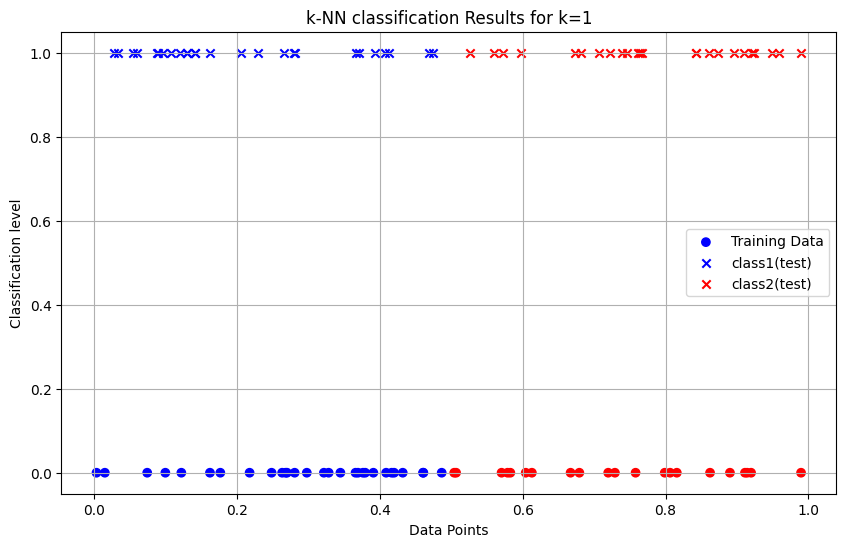

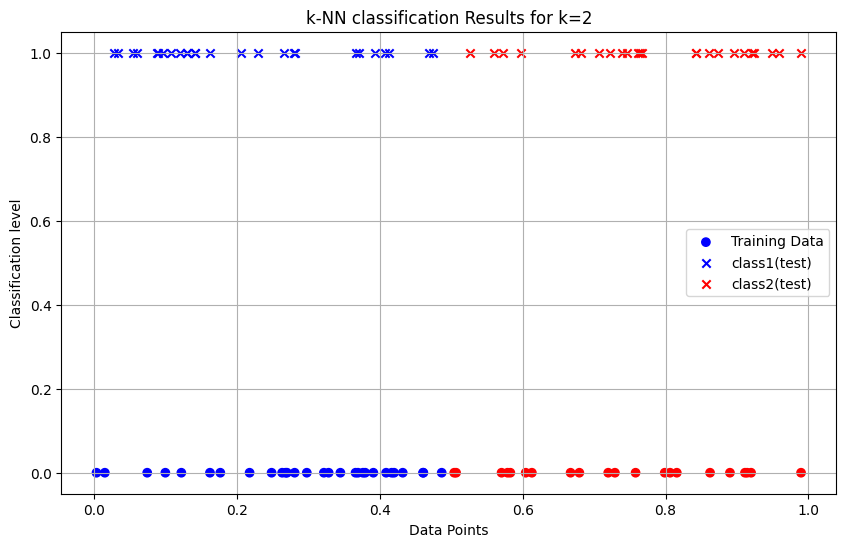

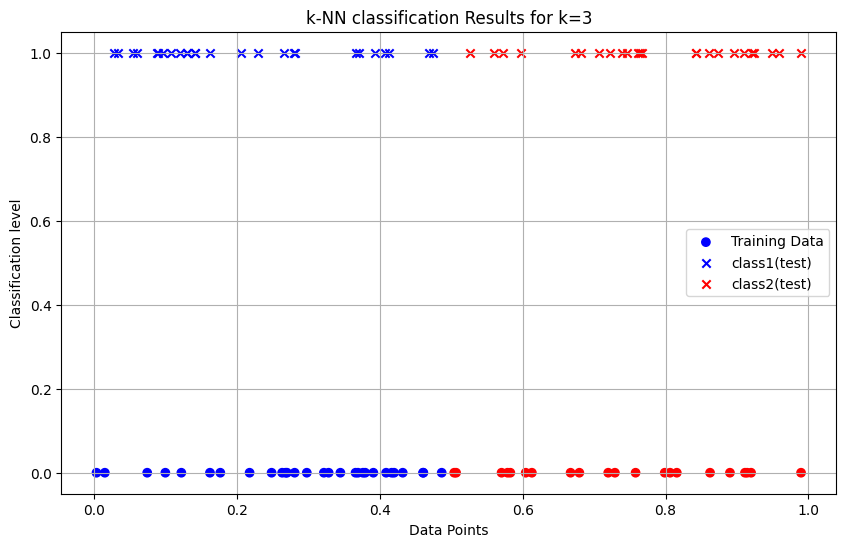

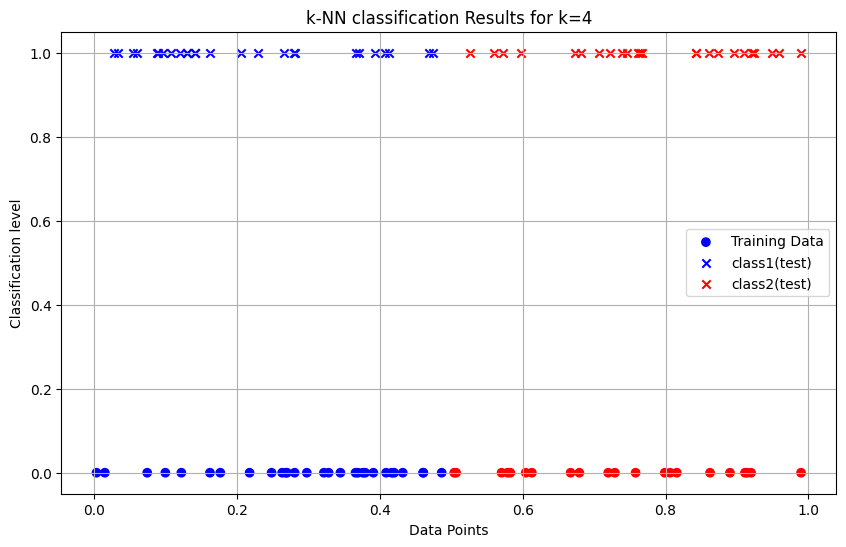

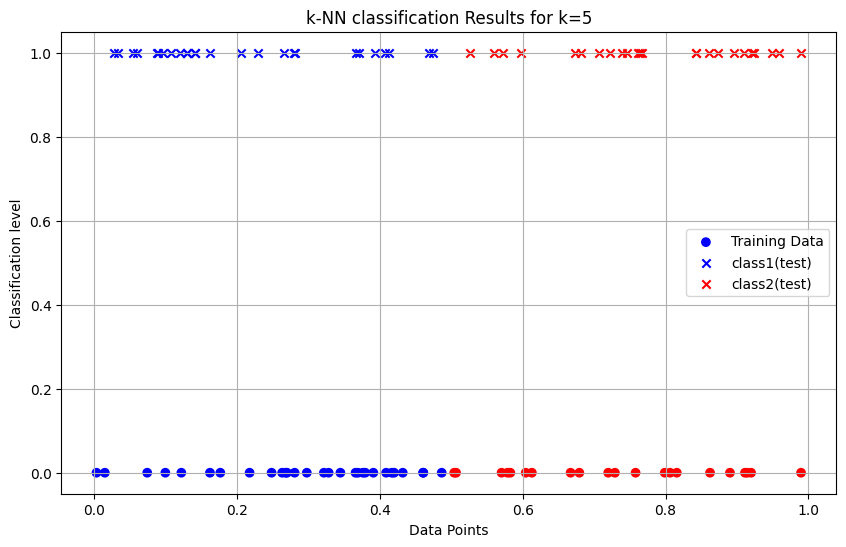

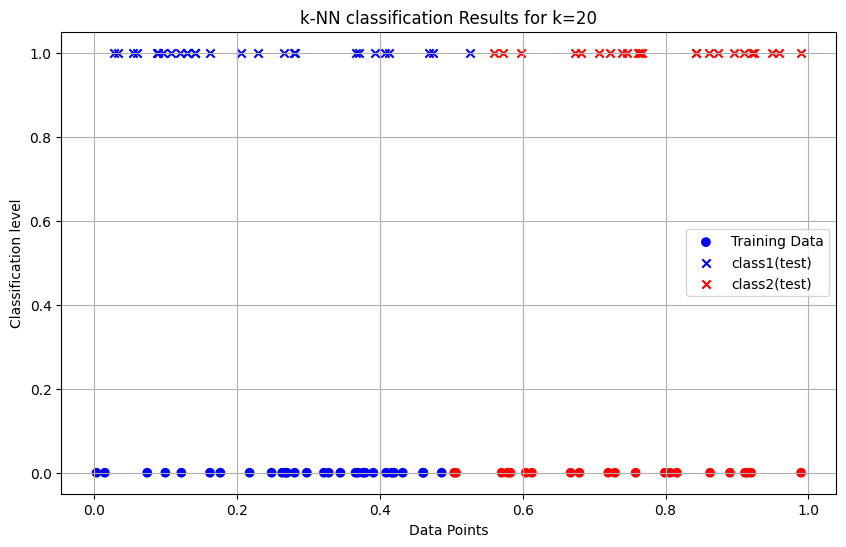

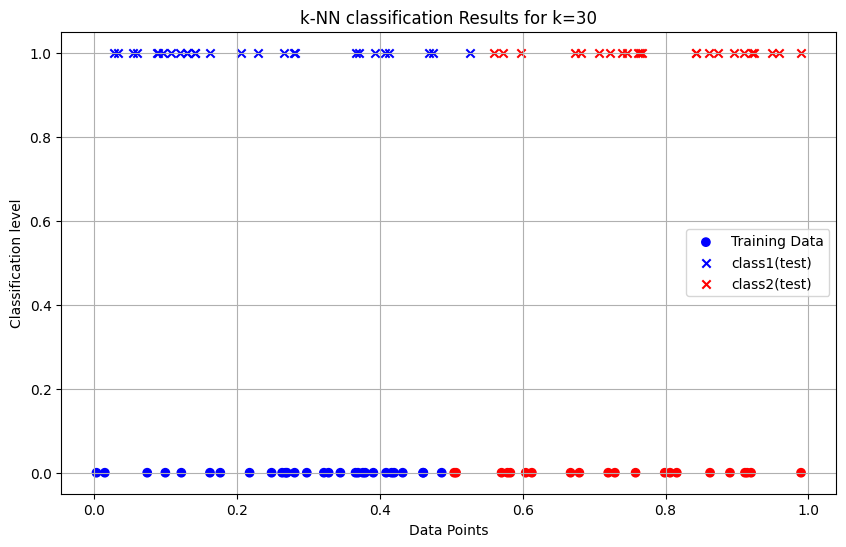

In [41]:
for k, classified_labels in result.items():
  class1_points=[test_data[i] for i in range (len(test_data)) if classified_labels[i]=="class"]
  class2_points=[test_data[i] for i in range(len(test_data)) if classified_labels[i]=="class2"]
  plt.figure(figsize=(10,6))
  plt.scatter(train_data, [0]*len(train_data), c=["blue" if lbl == "class" else "red" for lbl in train_labels], label="Training Data", marker="o")
  plt.scatter(class1_points,[1]*len(class1_points),c="blue",label="class1(test)",marker="x")
  plt.scatter(class2_points,[1]*len(class2_points), c="red", label="class2(test)",marker="x")
  plt.title(f"k-NN classification Results for k={k}")
  plt.xlabel("Data Points")
  plt.ylabel("Classification level")
  plt.legend()
  plt.grid(True)
  plt.show()